# Traffic metrics

##Libraries


In [265]:
!git clone -b feature/cv-yolo-detection https://github.com/Govind-2004/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization.git

fatal: destination path 'AI_Adaptive_Traffic_Analysis_and_Signal_Optimization' already exists and is not an empty directory.


In [266]:
%cd /content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization

/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization


In [267]:
# Install ByteTrack dependency
!pip install -q lap

In [268]:
# Install required packages
!pip install -q ultralytics

In [269]:
# Import libraries required for traffic metric analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib.util
import os
import cv2
import sys
from datetime import datetime



## Locate Data


In [270]:
# Project root directory
repo_path = "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization"

# Expected tracking data location
tracking_data_path = os.path.join(repo_path, "cv", "output", "tracking_data.csv")

print("Tracking data path:")
print(tracking_data_path)


Tracking data path:
/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/output/tracking_data.csv


In [271]:
# Locate tracking_data.csv if it is not at the expected path
found_path = None

if os.path.exists(tracking_data_path):
    found_path = tracking_data_path
else:
    print("Tracking data not found at the expected location. Searching /content ...")
    for root, dirs, files in os.walk("/content"):
        if "tracking_data.csv" in files:
            found_path = os.path.join(root, "tracking_data.csv")
            break

if found_path:
    tracking_data_path = found_path
    print("Tracking data found:", tracking_data_path)
else:
    print("tracking_data.csv not found anywhere. Will generate it in the next cell.")

Tracking data found: /content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/output/tracking_data.csv


In [272]:
detector_path = "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/detection/detector.py"

print("Exists:", os.path.exists(detector_path))

spec = importlib.util.spec_from_file_location(
    "detector_module",
    detector_path
)

detector = importlib.util.module_from_spec(spec)

spec.loader.exec_module(detector)

print("SUCCESS!")
print(detector.VEHICLE_CLASSES)

Exists: True
SUCCESS!
{2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}


In [273]:
# GENERATE TRACKING DATA
# YOLO Vehicle Detection + ByteTrack

if found_path is None:

    print("Starting tracking-data generation...")

    # Load YOLO model
    model, device = detector.load_model()

    print("YOLO model loaded successfully.")
    print("Running on:", device)
    print("Vehicle classes:", detector.VEHICLE_CLASSES)

    # Mount Google Drive
    from google.colab import drive

    drive.mount("/content/drive")

    #  Define traffic video path
    video_path = os.path.join(
        "/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo",
        "854671-hd_1920_1080_25fps.mp4"
    )

    print("\nVideo path:")
    print(video_path)

    # Check whether video exists
    if not os.path.exists(video_path):
        raise FileNotFoundError(
            f"\nTraffic video not found:\n{video_path}"
        )

    print("Video file found.")

    #  Open video and read basic information
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(
            "Could not open the traffic video."
        )

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    fps = cap.get(cv2.CAP_PROP_FPS)

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    print("\nVideo information:")
    print("Resolution:", width, "x", height)
    print("FPS:", fps)
    print("Total frames:", total_frames)

    cap.release()

    #  Start YOLO + ByteTrack
    print("\nStarting YOLO + ByteTrack processing...")
    print("This may take some time.")

    results = model.track(
        source=video_path,

        # Detect only vehicle classes
        classes=list(
            detector.VEHICLE_CLASSES.keys()
        ),

        # Minimum detection confidence
        conf=0.35,

        # ByteTrack tracker
        tracker="bytetrack.yaml",

        # Maintain tracking IDs
        persist=True,

        # Process results frame by frame
        stream=True,

        # Disable unnecessary console output
        verbose=False
    )

    #  Create storage for tracking data
    tracking_data = []

    frame_count = 0
    #  Process every frame
    for r in results:

        # Check whether ByteTrack assigned IDs
        if r.boxes.id is not None:

            # Process every tracked vehicle
            for box, track_id in zip(
                r.boxes,
                r.boxes.id
            ):

                # Tracking ID
                track_id = int(track_id)

                # Vehicle class
                class_id = int(box.cls[0])

                cls_name = detector.VEHICLE_CLASSES[
                    class_id
                ]

                # Bounding-box coordinates
                x1, y1, x2, y2 = (
                    box.xyxy[0]
                    .cpu()
                    .numpy()
                )

                # Calculate vehicle center point
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2

                # Store tracking information
                tracking_data.append({
                    "frame": frame_count,
                    "track_id": track_id,
                    "class": cls_name,
                    "center_x": center_x,
                    "center_y": center_y
                })

        # Move to next frame
        frame_count += 1

        # Display progress every 100 frames
        if frame_count % 100 == 0:
            print(
                f"Processed "
                f"{frame_count}/{total_frames} frames"
            )


    #  Convert tracking data to DataFrame
    df_generated = pd.DataFrame(
        tracking_data
    )

    print("\n========================================")
    print("TRACKING PROCESS COMPLETED")
    print("========================================")

    print("Frames processed:", frame_count)
    print("Tracking records:", len(df_generated))

    #  Validate generated data
    if df_generated.empty:
        raise RuntimeError(
            "No tracking data was generated. "
            "Check the video and YOLO settings."
        )

    # Check required columns
    required_columns = [
        "frame",
        "track_id",
        "class",
        "center_x",
        "center_y"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df_generated.columns
    ]

    if missing_columns:
        raise RuntimeError(
            f"Missing columns: {missing_columns}"
        )

    #  Display tracking statistics
    unique_vehicles = (
        df_generated["track_id"].nunique()
    )

    print(
        "Unique tracked vehicles:",
        unique_vehicles
    )

    print("\nVehicle classes detected:")

    print(
        df_generated["class"].value_counts()
    )

    #  Save tracking data
    os.makedirs(
        os.path.dirname(tracking_data_path),
        exist_ok=True
    )

    df_generated.to_csv(
        tracking_data_path,
        index=False
    )

    print("\nTracking data saved successfully:")
    print(tracking_data_path)

    #  Display first few records
    print("\nFirst 5 tracking records:")

    display(
        df_generated.head()
    )

else:

    print(
        "Skipping generation - "
        "tracking_data.csv already found."
    )

Skipping generation - tracking_data.csv already found.


In [274]:
# Load the tracking dataset
df = pd.read_csv(tracking_data_path)

print("Tracking data loaded successfully.")
print("Number of records:", len(df))


Tracking data loaded successfully.
Number of records: 8893


### Inspect Tracking Dataset


In [275]:
# Inspect dataset dimensions and sample records
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst five records:")
display(df.head())


Dataset shape: (8893, 5)

Column names:
['frame', 'track_id', 'class', 'center_x', 'center_y']

First five records:


,frame,track_id,class,center_x,center_y
0,0,1,car,1348.63260,565.07916
1,0,2,bus,1001.88390,376.22260
2,0,3,car,753.64404,492.73172
3,0,4,car,1035.10200,964.63074
4,0,5,car,922.09314,672.22015


### Validate Required Columns


In [276]:
# Required columns for traffic metric calculation
required_columns = ["frame", "track_id", "class", "center_x", "center_y"]
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
print("All required columns are available.")


All required columns are available.


### Check Missing Values and Data Types


In [277]:
# Check data types and missing values
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df[required_columns].isnull().sum())


Data types:
frame         int64
track_id      int64
class        object
center_x    float64
center_y    float64
dtype: object

Missing values:
frame       0
track_id    0
class       0
center_x    0
center_y    0
dtype: int64


##  Tracking Statistics




In [278]:
# Calculate basic tracking statistics
total_frames = df["frame"].nunique()
total_tracked_vehicles = df["track_id"].nunique()

print("Total frames containing tracking data:", total_frames)
print("Total unique tracked vehicles:", total_tracked_vehicles)


Total frames containing tracking data: 1501
Total unique tracked vehicles: 224


In [279]:
# Count unique tracked vehicles by vehicle class
class_distribution_df = (
    df.groupby("class")["track_id"]
      .nunique()
      .reset_index(name="vehicle_count")
)

display(class_distribution_df)


,class,vehicle_count
0,bus,11
1,car,146
2,motorcycle,2
3,truck,150


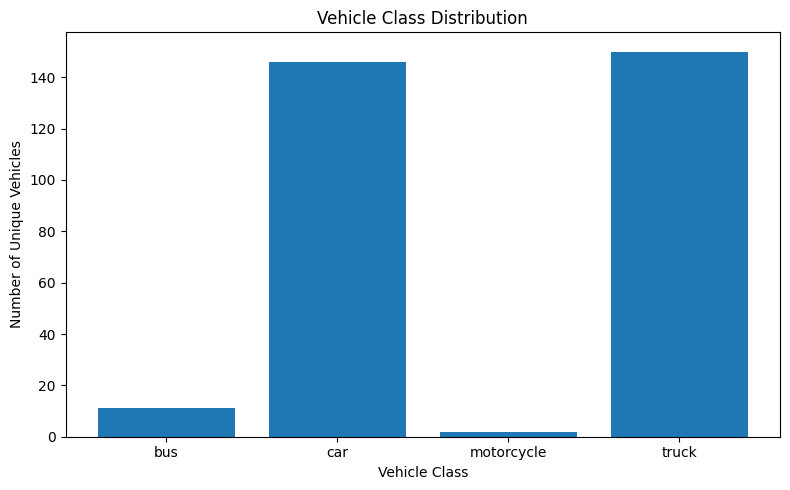

In [280]:
# Plot unique vehicles by class
plt.figure(figsize=(8, 5))
plt.bar(class_distribution_df["class"].astype(str), class_distribution_df["vehicle_count"])
plt.xlabel("Vehicle Class")
plt.ylabel("Number of Unique Vehicles")
plt.title("Vehicle Class Distribution")
plt.tight_layout()
plt.show()


### Vehicle Count Per Frame



In [281]:
# Calculate the number of unique vehicles present in each frame
frame_counts = (
    df.groupby("frame")["track_id"]
      .nunique()
      .reset_index(name="vehicle_count")
)

print("Frame-wise vehicle counts calculated successfully.")
display(frame_counts.head(10))


Frame-wise vehicle counts calculated successfully.


,frame,vehicle_count
0,0,10
1,1,8
2,2,8
3,3,9
4,4,9
5,5,9
6,6,11
7,7,13
8,8,12
9,9,12


In [282]:
# Calculate summary statistics for frame-wise vehicle count
display(frame_counts["vehicle_count"].describe())


,vehicle_count
count,1501.000000
mean,5.924717
std,1.864134
min,2.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,13.000000


### Vehicle Count Over Time


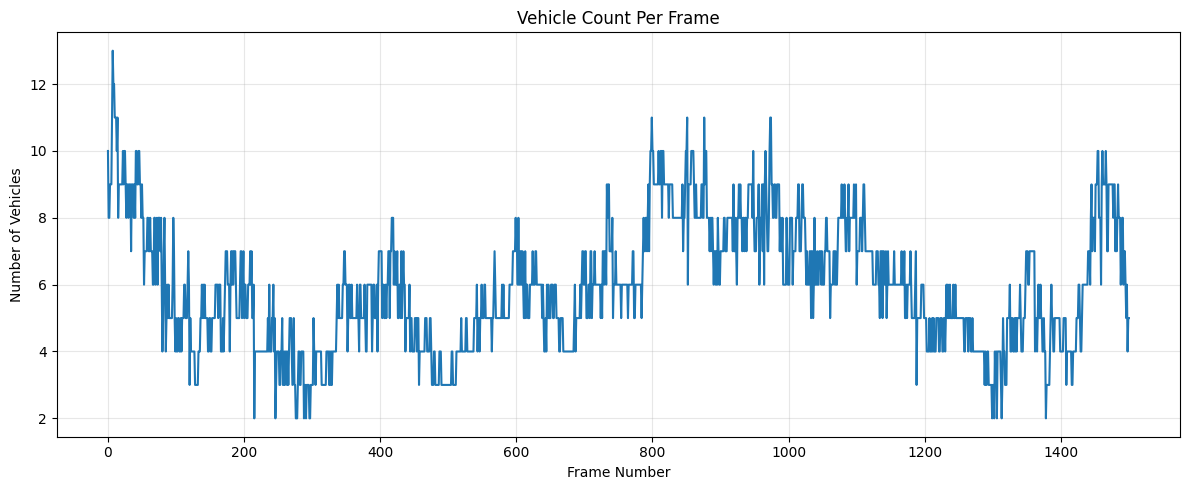

In [283]:
# Plot vehicle count for each frame
plt.figure(figsize=(12, 5))
plt.plot(frame_counts["frame"], frame_counts["vehicle_count"])
plt.xlabel("Frame Number")
plt.ylabel("Number of Vehicles")
plt.title("Vehicle Count Per Frame")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [284]:
# Calculate a moving average to smooth short-term fluctuations
window_size = 15
frame_counts["smoothed_count"] = frame_counts["vehicle_count"].rolling(window=window_size, min_periods=1).mean()
display(frame_counts.head())


,frame,vehicle_count,smoothed_count
0,0,10,10.000000
1,1,8,9.000000
2,2,8,8.666667
3,3,9,8.750000
4,4,9,8.800000


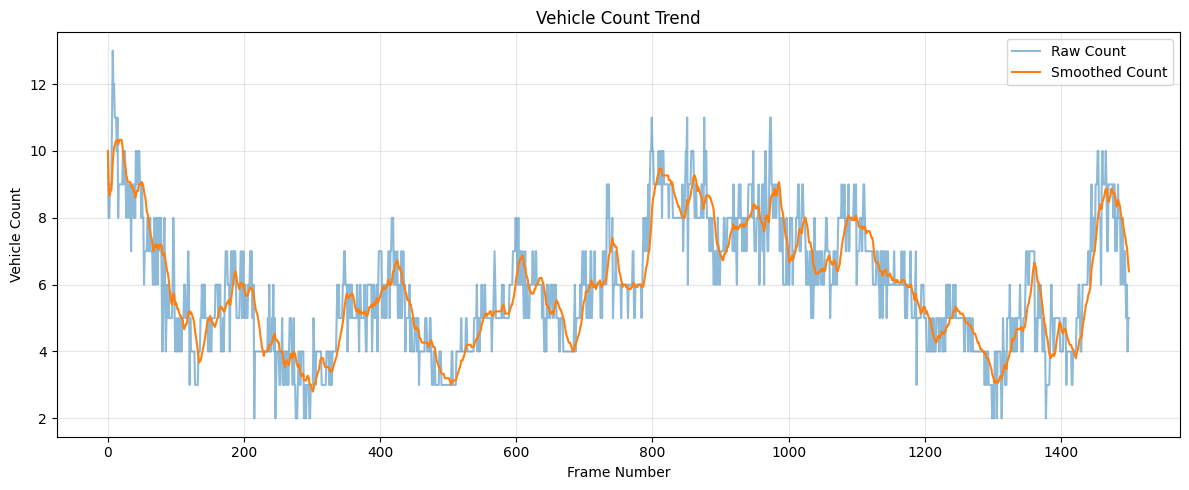

In [285]:
# Plot raw and smoothed vehicle counts
plt.figure(figsize=(12, 5))
plt.plot(frame_counts["frame"], frame_counts["vehicle_count"], label="Raw Count", alpha=0.5)
plt.plot(frame_counts["frame"], frame_counts["smoothed_count"], label="Smoothed Count")
plt.xlabel("Frame Number")
plt.ylabel("Vehicle Count")
plt.title("Vehicle Count Trend")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [286]:
# Calculate unique tracked vehicle counts by class for every frame
class_frame_counts = (
    df.groupby(["frame", "class"])["track_id"]
      .nunique()
      .reset_index(name="count")
)
display(class_frame_counts.head(10))


,frame,class,count
0,0,bus,2
1,0,car,7
2,0,truck,1
3,1,bus,1
4,1,car,7
5,2,bus,1
6,2,car,7
7,3,bus,2
8,3,car,7
9,4,bus,2


In [287]:
# Convert vehicle classes into separate columns
class_frame_table = (
    class_frame_counts.pivot(index="frame", columns="class", values="count")
    .fillna(0).reset_index()
)
display(class_frame_table.head())


class,frame,bus,car,motorcycle,truck
0,0,2.0,7.0,0.0,1.0
1,1,1.0,7.0,0.0,0.0
2,2,1.0,7.0,0.0,0.0
3,3,2.0,7.0,0.0,0.0
4,4,2.0,7.0,0.0,0.0


## Traffic Composition




In [288]:
# Calculate percentage composition of tracked vehicle classes
total_class_vehicles = class_distribution_df["vehicle_count"].sum()
class_distribution_df["percentage"] = class_distribution_df["vehicle_count"] / total_class_vehicles * 100
display(class_distribution_df)


,class,vehicle_count,percentage
0,bus,11,3.559871
1,car,146,47.249191
2,motorcycle,2,0.647249
3,truck,150,48.543689


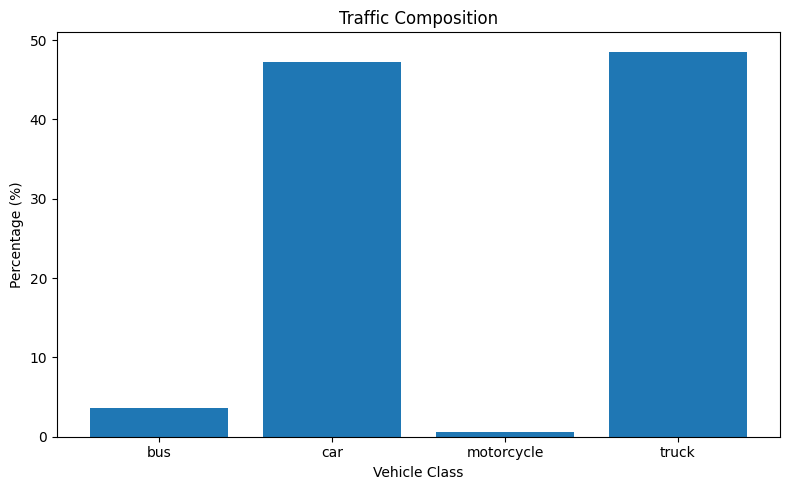

In [289]:
# Visualize traffic composition
plt.figure(figsize=(8, 5))
plt.bar(class_distribution_df["class"].astype(str), class_distribution_df["percentage"])
plt.xlabel("Vehicle Class")
plt.ylabel("Percentage (%)")
plt.title("Traffic Composition")
plt.tight_layout()
plt.show()


##  Vehicle Trajectory Analysis




In [290]:
# Sort observations by vehicle ID and frame
trajectory_df = df.sort_values(by=["track_id", "frame"]).copy()
display(trajectory_df.head(10))


,frame,track_id,class,center_x,center_y
0,0,1,car,1348.6326,565.07916
10,1,1,car,1355.2588,570.17800
18,2,1,car,1361.1165,574.14720
26,3,1,car,1368.6697,580.53530
35,4,1,car,1377.3251,586.59310
44,5,1,car,1383.2717,591.57434
53,6,1,car,1390.6392,596.20970
64,7,1,car,1397.9331,601.07910
77,8,1,car,1406.4849,607.74340
89,9,1,car,1413.8608,613.23425


### Inspect an Individual Vehicle Trajectory


In [291]:
# Select the first available vehicle ID
sample_track_id = trajectory_df["track_id"].iloc[0]
vehicle_trajectory = trajectory_df[trajectory_df["track_id"] == sample_track_id]
print("Selected Track ID:", sample_track_id)
print("Number of observations:", len(vehicle_trajectory))
display(vehicle_trajectory.head())


Selected Track ID: 1
Number of observations: 66


,frame,track_id,class,center_x,center_y
0,0,1,car,1348.6326,565.07916
10,1,1,car,1355.2588,570.17800
18,2,1,car,1361.1165,574.14720
26,3,1,car,1368.6697,580.53530
35,4,1,car,1377.3251,586.59310


###  Plot Vehicle Trajectory


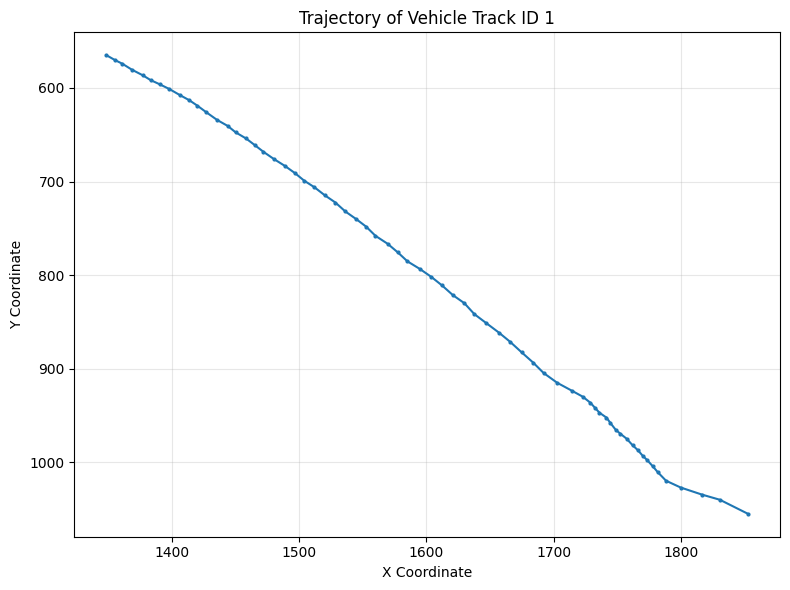

In [292]:
# Plot the trajectory of one tracked vehicle
plt.figure(figsize=(8, 6))
plt.plot(vehicle_trajectory["center_x"], vehicle_trajectory["center_y"], marker="o", markersize=2)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title(f"Trajectory of Vehicle Track ID {sample_track_id}")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Vehicle Movement Analysis



In [293]:
# Calculate frame-to-frame coordinate changes for each tracked vehicle
trajectory_df["delta_x"] = trajectory_df.groupby("track_id")["center_x"].diff()
trajectory_df["delta_y"] = trajectory_df.groupby("track_id")["center_y"].diff()

# Calculate displacement in pixels
trajectory_df["pixel_displacement"] = np.sqrt(trajectory_df["delta_x"] ** 2 + trajectory_df["delta_y"] ** 2)

display(trajectory_df[["frame", "track_id", "center_x", "center_y", "pixel_displacement"]].head(10))


,frame,track_id,center_x,center_y,pixel_displacement
0,0,1,1348.6326,565.07916,NaN
10,1,1,1355.2588,570.17800,8.360903
18,2,1,1361.1165,574.14720,7.075818
26,3,1,1368.6697,580.53530,9.892353
35,4,1,1377.3251,586.59310,10.564700
44,5,1,1383.2717,591.57434,7.757242
53,6,1,1390.6392,596.20970,8.704402
64,7,1,1397.9331,601.07910,8.769951
77,8,1,1406.4849,607.74340,10.841872
89,9,1,1413.8608,613.23425,9.195289


### Average Pixel Movement


In [294]:
# Calculate average frame-to-frame displacement
average_pixel_displacement = trajectory_df["pixel_displacement"].dropna().mean()
print("Average frame-to-frame displacement:", round(average_pixel_displacement, 2), "pixels")


Average frame-to-frame displacement: 5.09 pixels


In [295]:
!ls cv/traffic/

count.py  __init__.py  __pycache__


In [296]:
# Testing count.py

sys.path.insert(
    0,
    "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv"
)

from traffic.count import count_vehicles, class_distribution

print("count.py imported successfully!")

count.py imported successfully!


In [297]:
frame_counts, class_frame_counts = count_vehicles(df)

print("Frame-wise vehicle counts:")
display(frame_counts.head(10))

print("Class-wise vehicle counts:")
display(class_frame_counts.head(10))

print("Overall class distribution:")
display(class_distribution(df))

Frame-wise vehicle counts:


,frame,vehicle_count
0,0,10
1,1,8
2,2,8
3,3,9
4,4,9
5,5,9
6,6,11
7,7,13
8,8,12
9,9,12


Class-wise vehicle counts:


class,frame,bus,car,motorcycle,truck
0,0,2.0,7.0,0.0,1.0
1,1,1.0,7.0,0.0,0.0
2,2,1.0,7.0,0.0,0.0
3,3,2.0,7.0,0.0,0.0
4,4,2.0,7.0,0.0,0.0
5,5,2.0,7.0,0.0,0.0
6,6,2.0,8.0,0.0,1.0
7,7,2.0,9.0,0.0,2.0
8,8,1.0,9.0,0.0,2.0
9,9,1.0,9.0,0.0,2.0


Overall class distribution:


,class,vehicle_count
0,bus,11
1,car,146
2,motorcycle,2
3,truck,150


#ROI / Lane Assignment

In [298]:
# Pulling a real frame from demo footage

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [299]:
video_path = "/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/854671-hd_1920_1080_25fps.mp4"  # confirm this matches your actual path

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
print("Read successful:", ret)

Read successful: True


## Setting the ROI

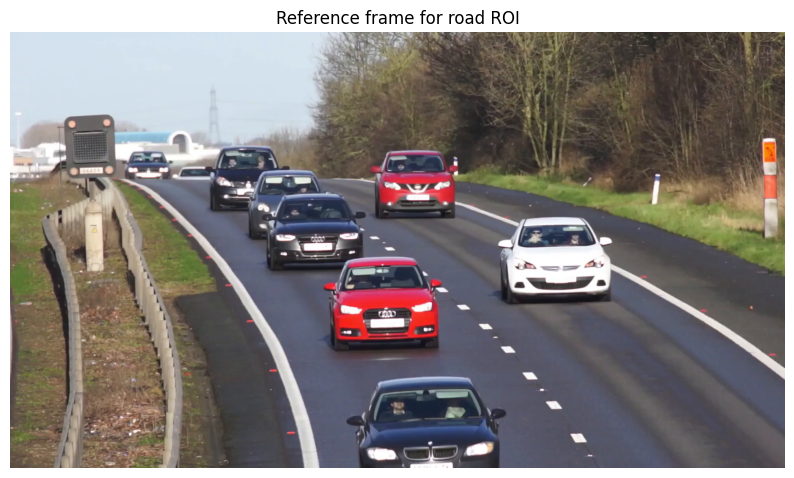

In [300]:
# Displaying the footage
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Reference frame for road ROI")
plt.show()

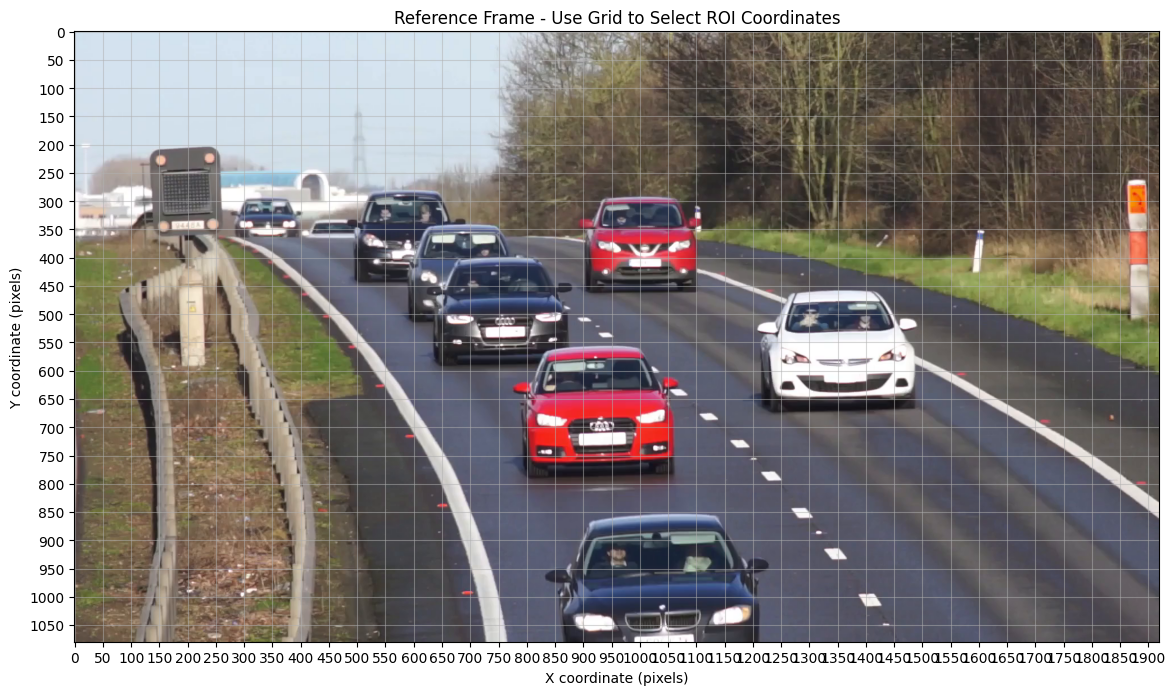

In [301]:
# Addinng grid to the frame inorder to identify coordinates to crea ROI

# Convert frame from BGR to RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Display the frame with coordinate grid
plt.figure(figsize=(14, 8))
plt.imshow(frame_rgb)

# Grid every 50 pixels
plt.xticks(np.arange(0, frame.shape[1], 50))
plt.yticks(np.arange(0, frame.shape[0], 50))

plt.grid(True, alpha=0.5)

plt.title("Reference Frame - Use Grid to Select ROI Coordinates")
plt.xlabel("X coordinate (pixels)")
plt.ylabel("Y coordinate (pixels)")

plt.show()

Road ROI: [(350, 300), (1000, 300), (1900, 950), (700, 1050)]


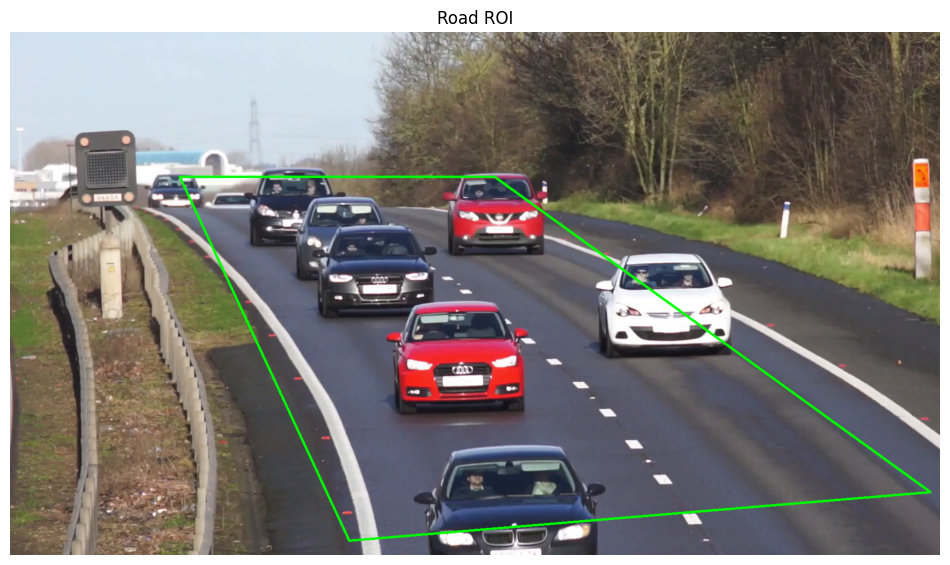

ROI coordinates: [(350, 300), (1000, 300), (1900, 950), (700, 1050)]


In [302]:
# Selecting the ROI

roi_points = [
    (350, 300),   # top-left, road edge near horizon
    (1000, 300),   # top-right, road edge near horizon
    (1900, 950),  # bottom-right, road edge at frame's right side
    (700, 1050)    # bottom-left, road edge near the barrier
]

print("Road ROI:", roi_points)

roi_polygon = np.array(roi_points, dtype=np.int32)

# Draw ROI on the reference frame
roi_frame = frame.copy()

cv2.polylines(
    roi_frame,
    [roi_polygon],
    isClosed=True,
    color=(0, 255, 0),
    thickness=3
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(roi_frame, cv2.COLOR_BGR2RGB))
plt.title("Road ROI")
plt.axis("off")
plt.show()

print("ROI coordinates:", roi_points)

## Applying ROI to full data

In [303]:
# Create camera configuration
camera_config = {
    "camera_1": {
        "direction": "north",
        "roi": roi_points
    }
}

print(camera_config)

{'camera_1': {'direction': 'north', 'roi': [(350, 300), (1000, 300), (1900, 950), (700, 1050)]}}


In [304]:
# Get camera config

active_camera = "camera_1"

# Get the ROI and direction for the active camera
roi_polygon = np.array(
    camera_config[active_camera]["roi"],
    dtype=np.int32
)

direction = camera_config[active_camera]["direction"]

print("Active camera:", active_camera)
print("Direction:", direction)
print("ROI points:", camera_config[active_camera]["roi"])

Active camera: camera_1
Direction: north
ROI points: [(350, 300), (1000, 300), (1900, 950), (700, 1050)]


In [305]:
# Check whether each tracked vehicle is inside the ROI

df["in_roi"] = df.apply(
    lambda row: cv2.pointPolygonTest(
        roi_polygon,
        (float(row["center_x"]), float(row["center_y"])),
        False
    ) >= 0,
    axis=1
)

# Keep only vehicles inside the road ROI
df_filtered = df[df["in_roi"]].copy()

print("Before filtering:", len(df))
print("After filtering:", len(df_filtered))
print("Dropped as non-road:", len(df) - len(df_filtered))

Before filtering: 8893
After filtering: 6788
Dropped as non-road: 2105


In [306]:
print("Unique vehicles before ROI:", df["track_id"].nunique())
print("Unique vehicles inside ROI:", df_filtered["track_id"].nunique())

Unique vehicles before ROI: 224
Unique vehicles inside ROI: 202


In [307]:
# Assign the physical approach direction from camera configuration

df_filtered["direction"] = direction

print("Direction assigned:", direction)

display(
    df_filtered[
        ["frame", "track_id", "class", "center_x", "center_y", "direction"]
    ].head(10)
)

Direction assigned: north


,frame,track_id,class,center_x,center_y,direction
0,0,1,car,1348.63260,565.07916,north
1,0,2,bus,1001.88390,376.22260,north
2,0,3,car,753.64404,492.73172,north
3,0,4,car,1035.10200,964.63074,north
4,0,5,car,922.09314,672.22015,north
5,0,6,car,677.11670,425.73523,north
8,0,9,truck,579.20710,361.98312,north
9,0,10,car,579.51794,363.19010,north
10,1,1,car,1355.25880,570.17800,north
11,1,2,bus,1004.54770,377.53552,north


In [308]:
# Reuse existing count.py for frame-wise counts
from traffic.count import count_vehicles

frame_counts_roi, _ = count_vehicles(df_filtered)

# Resolve one class per vehicle (most frequently detected label wins) —
# avoids double-counting a track that got mislabeled across different classes in different frames
track_class = df_filtered.groupby("track_id")["class"].agg(lambda x: x.value_counts().idxmax())
df_filtered["resolved_class"] = df_filtered["track_id"].map(track_class)

class_counts_roi = df_filtered.drop_duplicates("track_id")["resolved_class"].value_counts().reset_index()
class_counts_roi.columns = ["class", "vehicle_count"]

print("Frame-wise vehicle counts inside ROI:")
display(frame_counts_roi.head(10))

print("\nClass-wise vehicle counts inside ROI (corrected):")
display(class_counts_roi)
print("Sum of class counts:", class_counts_roi["vehicle_count"].sum())
print("Should equal total unique vehicles:", df_filtered["track_id"].nunique())

Frame-wise vehicle counts inside ROI:


,frame,vehicle_count
0,0,8
1,1,7
2,2,7
3,3,7
4,4,7
5,5,7
6,6,9
7,7,11
8,8,10
9,9,10



Class-wise vehicle counts inside ROI (corrected):


,class,vehicle_count
0,car,102
1,truck,97
2,motorcycle,2
3,bus,1


Sum of class counts: 202
Should equal total unique vehicles: 202


In [309]:
# Converting the CV results to contract format

class_count_dict = dict(
    zip(
        class_counts_roi["class"],
        class_counts_roi["vehicle_count"]
    )
)

traffic_block = {
    "vehicles": int(df_filtered["track_id"].nunique()),
    "cars": int(class_count_dict.get("car", 0)),
    "buses": int(class_count_dict.get("bus", 0)),
    "trucks": int(class_count_dict.get("truck", 0)),
    "motorcycles": int(class_count_dict.get("motorcycle", 0)),
    "average_speed": None,
    "queue_length": None
}

print("Traffic block:")
print(traffic_block)

Traffic block:
{'vehicles': 202, 'cars': 102, 'buses': 1, 'trucks': 97, 'motorcycles': 2, 'average_speed': None, 'queue_length': None}


In [310]:
# VERIFICATION CELL
print("TRAF-21 CV → ML Contract Check")
print("--------------------------------")
print("Direction:", direction)
print("Vehicles:", traffic_block["vehicles"])
print("Cars:", traffic_block["cars"])
print("Buses:", traffic_block["buses"])
print("Trucks:", traffic_block["trucks"])
print("Motorcycles:", traffic_block["motorcycles"])
print("Average speed:", traffic_block["average_speed"])
print("Queue length:", traffic_block["queue_length"])

TRAF-21 CV → ML Contract Check
--------------------------------
Direction: north
Vehicles: 202
Cars: 102
Buses: 1
Trucks: 97
Motorcycles: 2
Average speed: None
Queue length: None


In [311]:
traffic_state = {
    "junction_id": "J001",
    "timestamp": datetime.now().isoformat(),
    direction: traffic_block
}

print("CV → ML Traffic State:")
print(traffic_state)

CV → ML Traffic State:
{'junction_id': 'J001', 'timestamp': '2026-09-19T07:38:42.201530', 'north': {'vehicles': 202, 'cars': 102, 'buses': 1, 'trucks': 97, 'motorcycles': 2, 'average_speed': None, 'queue_length': None}}


# Speed Estimation

In [312]:
# Prepare tracking data for speed estimation

df_speed = df_filtered.copy()

print("Tracking data shape:", df_speed.shape)

print("\nColumns:")
print(df_speed.columns.tolist())

print("\nSample data:")
display(
    df_speed[
        [
            "frame",
            "track_id",
            "class",
            "center_x",
            "center_y",
            "direction"
        ]
    ].head(10)
)

Tracking data shape: (6788, 8)

Columns:
['frame', 'track_id', 'class', 'center_x', 'center_y', 'in_roi', 'direction', 'resolved_class']

Sample data:


,frame,track_id,class,center_x,center_y,direction
0,0,1,car,1348.63260,565.07916,north
1,0,2,bus,1001.88390,376.22260,north
2,0,3,car,753.64404,492.73172,north
3,0,4,car,1035.10200,964.63074,north
4,0,5,car,922.09314,672.22015,north
5,0,6,car,677.11670,425.73523,north
8,0,9,truck,579.20710,361.98312,north
9,0,10,car,579.51794,363.19010,north
10,1,1,car,1355.25880,570.17800,north
11,1,2,bus,1004.54770,377.53552,north


In [313]:
# Read FPS automatically from the video

cap = cv2.VideoCapture(video_path)

FPS = cap.get(cv2.CAP_PROP_FPS)

cap.release()

print("Video FPS:", FPS)

Video FPS: 25.0


In [314]:
df_speed["time_seconds"] = df_speed["frame"] / FPS
display(
    df_speed[
        ["frame", "track_id", "center_x", "center_y", "time_seconds"]
    ].head(15)
)

,frame,track_id,center_x,center_y,time_seconds
0,0,1,1348.63260,565.07916,0.00
1,0,2,1001.88390,376.22260,0.00
2,0,3,753.64404,492.73172,0.00
3,0,4,1035.10200,964.63074,0.00
4,0,5,922.09314,672.22015,0.00
5,0,6,677.11670,425.73523,0.00
8,0,9,579.20710,361.98312,0.00
9,0,10,579.51794,363.19010,0.00
10,1,1,1355.25880,570.17800,0.04
11,1,2,1004.54770,377.53552,0.04


In [315]:
# Calculate vehicle movement, frame2frame of each vehicle
df_speed = df_speed.sort_values(
    ["track_id", "frame"]
).copy()

df_speed["delta_x"] = (
    df_speed.groupby("track_id")["center_x"].diff()
)

df_speed["delta_y"] = (
    df_speed.groupby("track_id")["center_y"].diff()
)

df_speed["pixel_displacement"] = np.sqrt(
    df_speed["delta_x"] ** 2 +
    df_speed["delta_y"] ** 2
)

display(
    df_speed[
        [
            "frame",
            "track_id",
            "center_x",
            "center_y",
            "time_seconds",
            "delta_x",
            "delta_y",
            "pixel_displacement"
        ]
    ].head(20)
)

,frame,track_id,center_x,center_y,time_seconds,delta_x,delta_y,pixel_displacement
0,0,1,1348.6326,565.07916,0.00,NaN,NaN,NaN
10,1,1,1355.2588,570.17800,0.04,6.6262,5.09884,8.360903
18,2,1,1361.1165,574.14720,0.08,5.8577,3.96920,7.075818
26,3,1,1368.6697,580.53530,0.12,7.5532,6.38810,9.892353
35,4,1,1377.3251,586.59310,0.16,8.6554,6.05780,10.564700
44,5,1,1383.2717,591.57434,0.20,5.9466,4.98124,7.757242
53,6,1,1390.6392,596.20970,0.24,7.3675,4.63536,8.704402
64,7,1,1397.9331,601.07910,0.28,7.2939,4.86940,8.769951
77,8,1,1406.4849,607.74340,0.32,8.5518,6.66430,10.841872
89,9,1,1413.8608,613.23425,0.36,7.3759,5.49085,9.195289


In [316]:
# Calculate the actual time interval between observations

df_speed["frame_gap"] = (
    df_speed.groupby("track_id")["frame"].diff()
)

df_speed["time_delta"] = (
    df_speed.groupby("track_id")["time_seconds"].diff()
)

display(
    df_speed[
        [
            "frame",
            "track_id",
            "frame_gap",
            "time_delta",
            "pixel_displacement"
        ]
    ].head(20)
)

print("Frame-gap distribution:")
display(
    df_speed["frame_gap"]
    .value_counts()
    .sort_index()
)

print(
    "Maximum frame gap:",
    df_speed["frame_gap"].max()
)

print(
    "Percentage with consecutive frames:",
    round(
        (df_speed["frame_gap"] == 1).mean() * 100,
        2
    ),
    "%"
)

,frame,track_id,frame_gap,time_delta,pixel_displacement
0,0,1,NaN,NaN,NaN
10,1,1,1.0,0.04,8.360903
18,2,1,1.0,0.04,7.075818
26,3,1,1.0,0.04,9.892353
35,4,1,1.0,0.04,10.564700
44,5,1,1.0,0.04,7.757242
53,6,1,1.0,0.04,8.704402
64,7,1,1.0,0.04,8.769951
77,8,1,1.0,0.04,10.841872
89,9,1,1.0,0.04,9.195289


Frame-gap distribution:


,count
frame_gap,
1.0,6456
2.0,81
3.0,13
4.0,12
5.0,5
6.0,2
7.0,1
9.0,4
10.0,2


Maximum frame gap: 116.0
Percentage with consecutive frames: 95.11 %


In [317]:
# Keep reliable observations for speed calculation

MAX_FRAME_GAP = 5

df_speed_valid = df_speed[
    (df_speed["frame_gap"] >= 1) &
    (df_speed["frame_gap"] <= MAX_FRAME_GAP) &
    (df_speed["time_delta"] > 0)
].copy()

print("Original observations:", len(df_speed))
print("Valid speed observations:", len(df_speed_valid))
print(
    "Retained:",
    round(len(df_speed_valid) / len(df_speed) * 100, 2),
    "%"
)

print("\nFrame-gap distribution after filtering:")
display(
    df_speed_valid["frame_gap"]
    .value_counts()
    .sort_index()
)

Original observations: 6788
Valid speed observations: 6567
Retained: 96.74 %

Frame-gap distribution after filtering:


,count
frame_gap,
1.0,6456
2.0,81
3.0,13
4.0,12
5.0,5


In [318]:
# Calculate pixel speed

df_speed_valid["pixel_speed"] = (
    df_speed_valid["pixel_displacement"]
    / df_speed_valid["time_delta"]
)

display(
    df_speed_valid[
        [
            "frame",
            "track_id",
            "frame_gap",
            "pixel_displacement",
            "time_delta",
            "pixel_speed"
        ]
    ].head(20)
)

print("\nPixel-speed statistics:")
print(
    df_speed_valid["pixel_speed"].describe()
)

,frame,track_id,frame_gap,pixel_displacement,time_delta,pixel_speed
10,1,1,1.0,8.360903,0.04,209.022570
18,2,1,1.0,7.075818,0.04,176.895446
26,3,1,1.0,9.892353,0.04,247.308830
35,4,1,1.0,10.564700,0.04,264.117505
44,5,1,1.0,7.757242,0.04,193.931050
53,6,1,1.0,8.704402,0.04,217.610056
64,7,1,1.0,8.769951,0.04,219.248765
77,8,1,1.0,10.841872,0.04,271.046788
89,9,1,1.0,9.195289,0.04,229.882218
101,10,1,1.0,8.539945,0.04,213.498633



Pixel-speed statistics:
count    6567.000000
mean      135.923009
std        91.369120
min         1.292200
25%        62.837954
50%       110.566417
75%       192.725184
max       516.151803
Name: pixel_speed, dtype: float64


In [319]:
# Calculate median pixel speed for each vehicle

vehicle_speed_summary = (
    df_speed_valid
    .groupby("track_id")["pixel_speed"]
    .agg(
        mean_pixel_speed="mean",
        median_pixel_speed="median",
        min_pixel_speed="min",
        max_pixel_speed="max",
        observations="count"
    )
    .sort_values("median_pixel_speed")
)

display(vehicle_speed_summary.head(20))

print("\nVehicle-level pixel-speed statistics:")
print(
    vehicle_speed_summary["median_pixel_speed"].describe()
)

,mean_pixel_speed,median_pixel_speed,min_pixel_speed,max_pixel_speed,observations
track_id,,,,,
227,4.610282,4.610282,4.610282,4.610282,1
258,19.396032,19.396032,19.396032,19.396032,1
46,19.769483,19.769483,19.769483,19.769483,1
249,26.602197,26.602197,26.602197,26.602197,1
400,31.438364,31.438364,31.438364,31.438364,1
432,31.807793,31.807793,31.807793,31.807793,1
43,32.110059,32.110059,32.110059,32.110059,1
364,33.309457,33.309457,22.432281,44.186633,2
366,35.254643,33.850583,29.461308,42.452038,3



Vehicle-level pixel-speed statistics:
count    136.000000
mean      92.914651
std       55.963730
min        4.610282
25%       51.932023
50%       81.086395
75%      114.762512
max      362.716749
Name: median_pixel_speed, dtype: float64


In [320]:
# Keep vehicles with enough observations for a reliable speed estimate

MIN_SPEED_OBSERVATIONS = 10

reliable_vehicle_speeds = vehicle_speed_summary[
    vehicle_speed_summary["observations"] >= MIN_SPEED_OBSERVATIONS
].copy()

print(
    "Vehicles with at least",
    MIN_SPEED_OBSERVATIONS,
    "valid observations:",
    len(reliable_vehicle_speeds)
)

display(reliable_vehicle_speeds.head(20))

print("\nReliable vehicle median-speed statistics:")
print(
    reliable_vehicle_speeds["median_pixel_speed"].describe()
)

Vehicles with at least 10 valid observations: 41


,mean_pixel_speed,median_pixel_speed,min_pixel_speed,max_pixel_speed,observations
track_id,,,,,
291,42.324653,40.481334,18.440087,69.090969,15
397,87.778022,47.708619,18.350994,315.303080,11
414,48.142899,47.959691,24.333691,75.507800,43
423,52.436126,50.117661,23.811855,149.159870,53
443,54.231468,52.909837,34.171948,80.165228,14
365,57.952076,54.548531,14.864634,133.129782,30
424,62.511022,58.109509,15.220407,164.322115,63
206,105.111302,81.230035,14.814095,305.291137,254
48,110.014560,82.405069,8.121975,373.492826,275



Reliable vehicle median-speed statistics:
count     41.000000
mean     121.087839
std       56.789182
min       40.481334
25%       85.779991
50%      111.731805
75%      156.679424
max      277.543187
Name: median_pixel_speed, dtype: float64


In [321]:
#  Inspect speed stability for well-tracked vehicles

stable_candidates = (
    vehicle_speed_summary[
        vehicle_speed_summary["observations"] >= 100
    ]
    .sort_values("observations", ascending=False)
)

display(
    stable_candidates[
        [
            "mean_pixel_speed",
            "median_pixel_speed",
            "min_pixel_speed",
            "max_pixel_speed",
            "observations"
        ]
    ].head(10)
)

,mean_pixel_speed,median_pixel_speed,min_pixel_speed,max_pixel_speed,observations
track_id,,,,,
180,111.488676,85.932358,12.091606,347.326293,351
196,112.798569,92.698311,4.583787,366.249487,301
138,131.219575,87.784005,2.950194,431.165741,290
117,132.250866,99.523518,3.234783,427.075158,284
48,110.014560,82.405069,8.121975,373.492826,275
206,105.111302,81.230035,14.814095,305.291137,254
11,152.127939,108.740767,11.370936,461.672319,242
233,166.728274,175.244395,5.266246,395.647898,232
210,116.612345,99.017320,3.428621,440.483529,231


In [322]:
# Smooth pixel speed using a rolling median

df_speed_valid = df_speed_valid.sort_values(
    ["track_id", "frame"]
).copy()

df_speed_valid["smoothed_pixel_speed"] = (
    df_speed_valid
    .groupby("track_id")["pixel_speed"]
    .transform(
        lambda x: x.rolling(
            window=5,
            center=True,
            min_periods=1
        ).median()
    )
)

display(
    df_speed_valid[
        [
            "frame",
            "track_id",
            "pixel_speed",
            "smoothed_pixel_speed"
        ]
    ].head(20)
)

,frame,track_id,pixel_speed,smoothed_pixel_speed
10,1,1,209.022570,209.022570
18,2,1,176.895446,228.165700
26,3,1,247.308830,209.022570
35,4,1,264.117505,217.610056
44,5,1,193.931050,219.248765
53,6,1,217.610056,219.248765
64,7,1,219.248765,219.248765
77,8,1,271.046788,219.248765
89,9,1,229.882218,229.882218
101,10,1,213.498633,245.548209


In [323]:
# Calculate representative smoothed speed for each vehicle

vehicle_smoothed_speed = (
    df_speed_valid
    .groupby("track_id")["smoothed_pixel_speed"]
    .median()
    .rename("representative_pixel_speed")
    .to_frame()
)

vehicle_smoothed_speed = vehicle_smoothed_speed.join(
    vehicle_speed_summary["observations"]
)

print("Representative pixel speed per vehicle:")
display(vehicle_smoothed_speed.head(20))

print("\nStatistics:")
print(
    vehicle_smoothed_speed["representative_pixel_speed"].describe()
)

Representative pixel speed per vehicle:


,representative_pixel_speed,observations
track_id,,
1,275.840216,51
2,195.565268,106
3,219.427457,73
4,170.128358,9
5,265.501951,40
6,194.536120,91
7,115.180974,190
10,161.573750,120
11,104.834577,242



Statistics:
count    136.000000
mean      91.862021
std       55.592901
min        4.610282
25%       51.932023
50%       80.777346
75%      114.152175
max      362.716749
Name: representative_pixel_speed, dtype: float64


In [324]:
# Keep representative speeds for reliably tracked vehicles

reliable_vehicle_speeds = vehicle_smoothed_speed[
    vehicle_smoothed_speed["observations"] >= MIN_SPEED_OBSERVATIONS
].copy()

print(
    "Reliable vehicles:",
    len(reliable_vehicle_speeds)
)

display(
    reliable_vehicle_speeds
)

print("\nReliable representative pixel-speed statistics:")
print(
    reliable_vehicle_speeds["representative_pixel_speed"].describe()
)

Reliable vehicles: 41


,representative_pixel_speed,observations
track_id,,
1,275.840216,51
2,195.565268,106
3,219.427457,73
5,265.501951,40
6,194.536120,91
7,115.180974,190
10,161.573750,120
11,104.834577,242
48,76.747444,275



Reliable representative pixel-speed statistics:
count     41.000000
mean     117.533996
std       56.765578
min       40.481334
25%       82.830277
50%      109.294307
75%      137.544628
max      275.840216
Name: representative_pixel_speed, dtype: float64


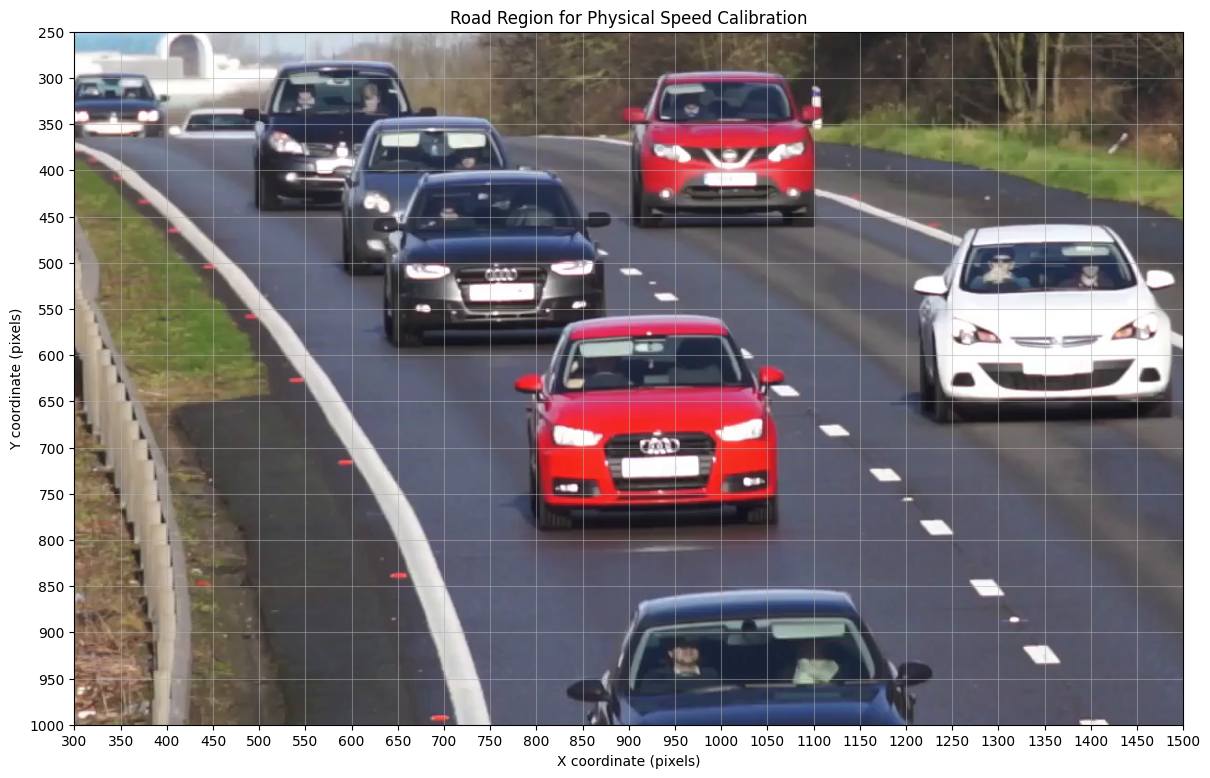

In [325]:
# Display the reference frame for physical calibration

plt.figure(figsize=(16, 9))
plt.imshow(frame_rgb)

plt.xlim(300, 1500)
plt.ylim(1000, 250)

plt.xticks(np.arange(300, 1501, 50))
plt.yticks(np.arange(250, 1001, 50))

plt.grid(True, alpha=0.5)

plt.title("Road Region for Physical Speed Calibration")
plt.xlabel("X coordinate (pixels)")
plt.ylabel("Y coordinate (pixels)")

plt.show()

In [326]:
# Prepare configurable physical speed calibration

# No physical calibration has been established for the current video.
# Therefore, keep the current result in pixels/second.

CALIBRATION_AVAILABLE = False

if CALIBRATION_AVAILABLE:
    METERS_PER_PIXEL = 0.0  # Set this only after establishing a real calibration

    reliable_vehicle_speeds["speed_mps"] = (
        reliable_vehicle_speeds["representative_pixel_speed"]
        * METERS_PER_PIXEL
    )

    reliable_vehicle_speeds["speed_kmph"] = (
        reliable_vehicle_speeds["speed_mps"] * 3.6
    )

else:
    reliable_vehicle_speeds["speed_mps"] = None
    reliable_vehicle_speeds["speed_kmph"] = None

print("Physical calibration available:", CALIBRATION_AVAILABLE)

display(
    reliable_vehicle_speeds[
        [
            "representative_pixel_speed",
            "observations",
            "speed_mps",
            "speed_kmph"
        ]
    ].head(10)
)

Physical calibration available: False


,representative_pixel_speed,observations,speed_mps,speed_kmph
track_id,,,,
1,275.840216,51,None,None
2,195.565268,106,None,None
3,219.427457,73,None,None
5,265.501951,40,None,None
6,194.536120,91,None,None
7,115.180974,190,None,None
10,161.573750,120,None,None
11,104.834577,242,None,None
48,76.747444,275,None,None


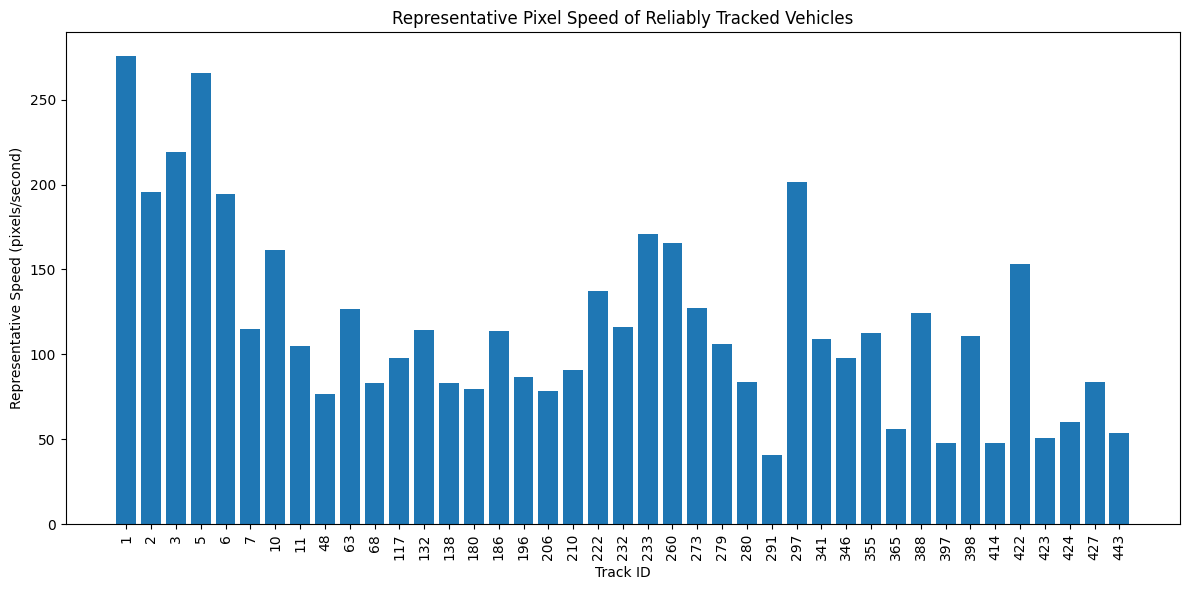

In [327]:
# Visualize representative pixel speed by vehicle

plt.figure(figsize=(12, 6))

plt.bar(
    reliable_vehicle_speeds.index.astype(str),
    reliable_vehicle_speeds["representative_pixel_speed"]
)

plt.xlabel("Track ID")
plt.ylabel("Representative Speed (pixels/second)")
plt.title("Representative Pixel Speed of Reliably Tracked Vehicles")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# Real-world speed calibration (homography) is deferred as an optional extension per team decision

In [ ]:
# # Physical speed calibration — deferred as an optional extension (team decision).
# # TRAF-30's core deliverable is validated relative (pixel-based) speed per vehicle.
# # Real-world km/h calibration via homography can be added later without changing this structure.

# CALIBRATION_AVAILABLE = False

# if CALIBRATION_AVAILABLE:
#     METERS_PER_PIXEL = 0.0  # Set this only after establishing a real calibration

#     reliable_vehicle_speeds["speed_mps"] = (
#         reliable_vehicle_speeds["representative_pixel_speed"] * METERS_PER_PIXEL
#     )
#     reliable_vehicle_speeds["speed_kmph"] = reliable_vehicle_speeds["speed_mps"] * 3.6
# else:
#     reliable_vehicle_speeds["speed_mps"] = None
#     reliable_vehicle_speeds["speed_kmph"] = None

# print("Physical calibration available:", CALIBRATION_AVAILABLE)

# display(
#     reliable_vehicle_speeds[
#         ["representative_pixel_speed", "observations", "speed_mps", "speed_kmph"]
#     ]
# )

# # Contract field — left as None per team decision, not a fabricated/wrong-unit value
# traffic_block["average_speed"] = None
# print("\ntraffic_block['average_speed']:", traffic_block["average_speed"])